<a href="https://colab.research.google.com/github/th900/imovel_valor/blob/main/previsao_imovel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Previsão de Preços de Imóveis para Otimização de Margem Imobiliária

## 1. O Problema de Negócio (Contexto)
Em um mercado imobiliário altamente competitivo, a precificação correta de um imóvel é um dos fatores mais críticos para o sucesso de uma imobiliária digital.

* **A Dor do Negócio:** Atualmente, o processo de avaliação de imóveis é feito de forma manual por corretores. Isso gera dois grandes problemas:
  1. **Subprecificação:** Imóveis são avaliados abaixo do valor de mercado, fazendo com que o proprietário e a imobiliária percam dinheiro na comissão.
  2. **Superprecificação:** Imóveis são avaliados acima do valor real, ficando "encalhados" no site por meses, gerando custos de anúncio e frustração para os clientes.
  3. **Lentidão:** O processo manual demora dias para analisar todas as variáveis da casa (área, qualidade, ano de construção, etc.).

## 1.1 O que o Algoritmo Resolve?
O objetivo deste projeto é construir um modelo de Machine Learning capaz de prever o preço de venda de um imóvel (`SalePrice`) com base em suas características estruturais e de localização.

* **Impacto Operacional:** Reduzir o tempo de avaliação de dias para segundos.
* **Impacto Financeiro:** Maximizar o volume de vendas ao sugerir preços competitivos e justos, diminuindo o tempo de imóvel parado no catálogo.

### 2) Leitura de dados

In [4]:
import os
from google.colab import userdata


os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [5]:
# Baixa o zip do dataset oficial de preços de casas
!kaggle competitions download -c house-prices-advanced-regression-techniques

# Descompacta os arquivos .csv
!unzip house-prices-advanced-regression-techniques.zip

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  house-prices-advanced-regression-techniques.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data_description.txt    
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sample_submission.csv   
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score,mean_absolute_error
import joblib

In [7]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [8]:
print(f"Quantidade de colunas do dataset de treino:{df_train.shape[1]} ")
print(f"Quantidade de linhas do dataset de treino: {df_train.shape[0]} ")
print(f"Quantidade de colunas do dataset de teste: {df_test.shape[1]} ")
print(f"Quantidade de linhas do dataset de teste: {df_test.shape[0]} ")

Quantidade de colunas do dataset de treino:81 
Quantidade de linhas do dataset de treino: 1460 
Quantidade de colunas do dataset de teste: 80 
Quantidade de linhas do dataset de teste: 1459 


In [9]:
df_train.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
df_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### 3) Limpeza e tratamento dos dados

In [11]:
valores_nulos = df_train.isnull().sum()

colunas_com_nulos = valores_nulos[valores_nulos > 0].sort_values(ascending=False)

print(colunas_com_nulos)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [12]:

df_clean = df_train.copy()

# Tratando colunas textuais onde nulo significa "Não possui"
text_cols_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1', 'MasVnrType'
]
for col in text_cols_none:
    df_clean[col] = df_clean[col].fillna('None')

#Tratando colunas numéricas específicas
df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0)
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)

# LotFrontage: Preenchendo com a mediana da frente dos lotes do mesmo bairro (Neighborhood)
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# Electrical: Tem apenas 1 nulo, vamos preencher com a moda (o tipo mais comum)
df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

# Removendo dois outliers que o criador do desafio disse para remover
linhas_antes = df_clean.shape[0]
df_train = df_clean.drop(df_train[(df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)].index)
linhas_depois = df_clean.shape[0]

# Verificação final: Garante que o total de nulos zerou
print(f"Total de valores nulos restantes: {df_clean.isnull().sum().sum()}")
print(f"Outliers removidos com sucesso! Linhas antes: {linhas_antes} | Linhas atuais: {linhas_depois}")

Total de valores nulos restantes: 0
Outliers removidos com sucesso! Linhas antes: 1460 | Linhas atuais: 1460


### 4) Análise exploratória dos dados




/tmp/ipykernel_950/2915917837.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='OverallQual', y='SalePrice', palette='Blues')


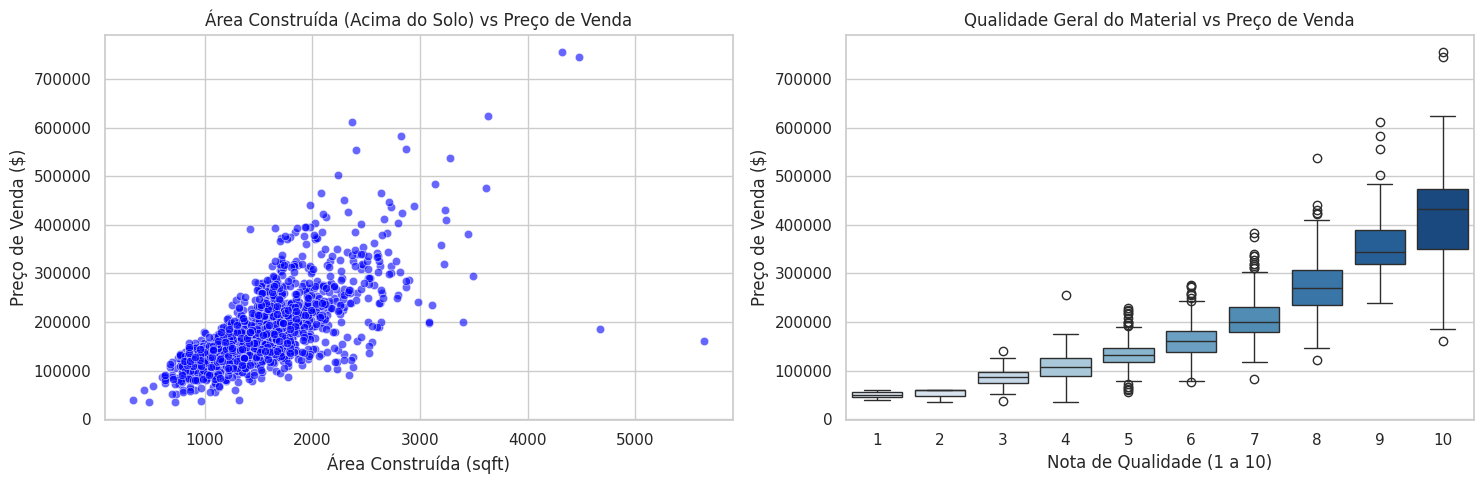

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 5))

# Gráfico 1: Tamanho da casa vs Preço
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean, x='GrLivArea', y='SalePrice', alpha=0.6, color='Blue')
plt.title('Área Construída (Acima do Solo) vs Preço de Venda')
plt.xlabel('Área Construída (sqft)')
plt.ylabel('Preço de Venda ($)')

# Gráfico 2: Qualidade Material vs Preço
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='OverallQual', y='SalePrice', palette='Blues')
plt.title('Qualidade Geral do Material vs Preço de Venda')
plt.xlabel('Nota de Qualidade (1 a 10)')
plt.ylabel('Preço de Venda ($)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_950/909063815.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Neighborhood', y='SalePrice', order=bairros_valorizados, palette='Blues')


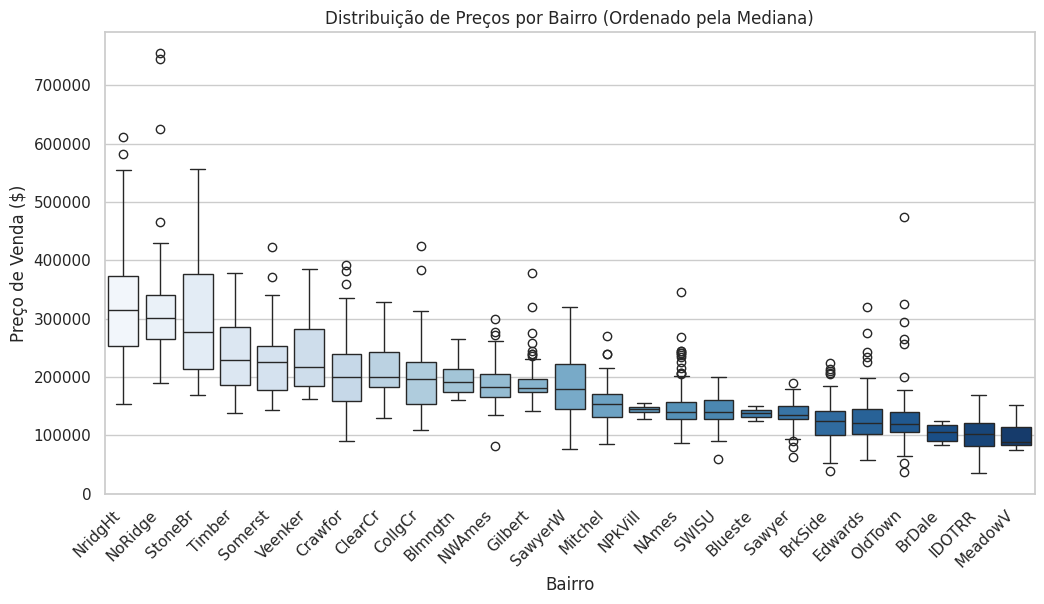

In [14]:
plt.figure(figsize=(12, 6))

# Calculando a média de preço por bairro
bairros_valorizados = df_clean.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

sns.boxplot(data=df_clean, x='Neighborhood', y='SalePrice', order=bairros_valorizados, palette='Blues')
plt.xticks(rotation=45, ha='right')
plt.title('Distribuição de Preços por Bairro (Ordenado pela Mediana)')
plt.xlabel('Bairro')
plt.ylabel('Preço de Venda ($)')
plt.show()

/tmp/ipykernel_950/1844399936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='HouseStyle', order=df_clean['HouseStyle'].value_counts().index, palette='Blues_r')


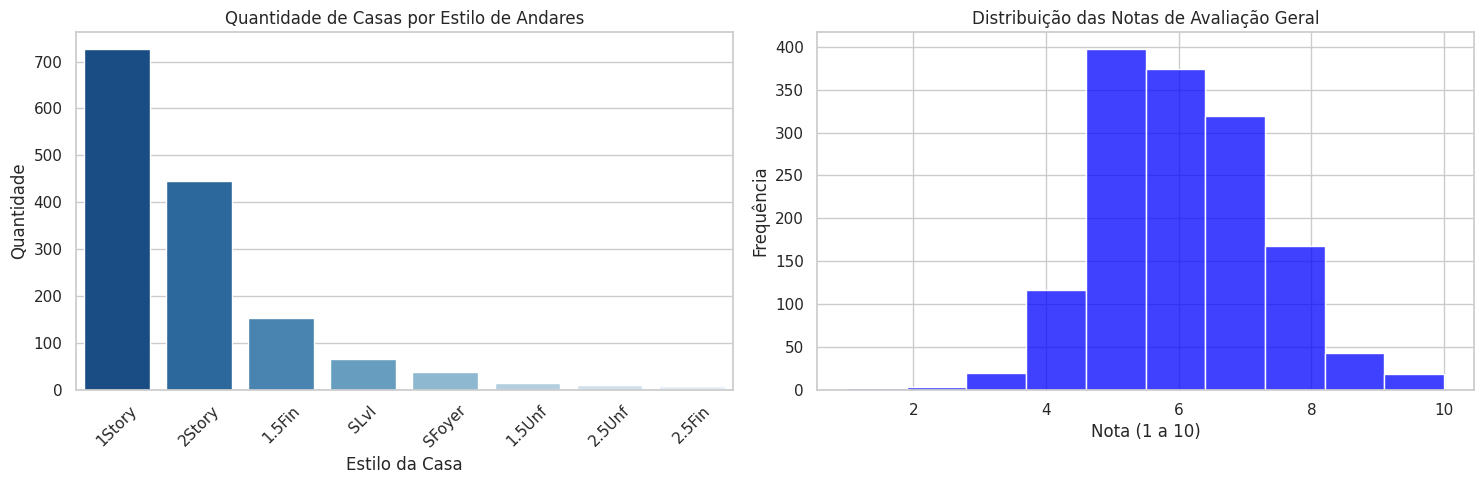

In [15]:
plt.figure(figsize=(15, 5))

# Gráfico 1: Quantidade de Casas por Estilo/Andares
plt.subplot(1, 2, 1)
sns.countplot(data=df_clean, x='HouseStyle', order=df_clean['HouseStyle'].value_counts().index, palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Quantidade de Casas por Estilo de Andares')
plt.xlabel('Estilo da Casa')
plt.ylabel('Quantidade')

# Gráfico 2: Média de Avaliação Geral das Casas
plt.subplot(1, 2, 2)
sns.histplot(df_clean['OverallQual'], kde=False, color='Blue', bins=10)
plt.title('Distribuição das Notas de Avaliação Geral')
plt.xlabel('Nota (1 a 10)')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

/tmp/ipykernel_950/1073484323.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Tem_Piscina', y='SalePrice', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_950/1073484323.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Tem_Lareira', y='SalePrice', ax=axes[1], palette='Blues_r')
/tmp/ipykernel_950/1073484323.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Tem_Porao', y='SalePrice', ax=axes[2], palette='Blues_r')


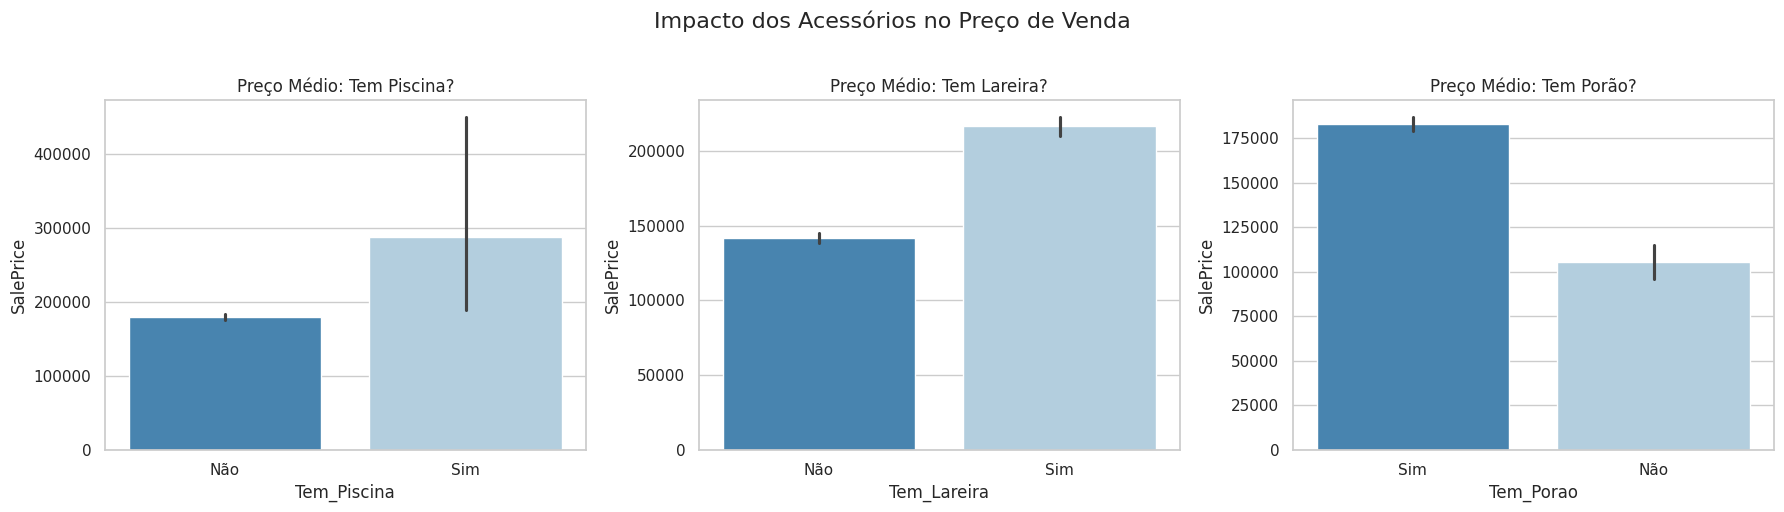

Casas com Piscina: 7
Casas com Lareira: 770
Casas com Porão: 1423


In [16]:
# Criando colunas temporárias indicando se possui o acessório
df_clean['Tem_Piscina'] = df_clean['PoolQC'].apply(lambda x: 'Não' if x == 'None' else 'Sim')
df_clean['Tem_Lareira'] = df_clean['Fireplaces'].apply(lambda x: 'Não' if x == 0 else 'Sim')
df_clean['Tem_Porao'] = df_clean['TotalBsmtSF'].apply(lambda x: 'Não' if x == 0 else 'Sim')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráficos de barras comparando os preços médios
sns.barplot(data=df_clean, x='Tem_Piscina', y='SalePrice', ax=axes[0], palette='Blues_r')
axes[0].set_title('Preço Médio: Tem Piscina?')

sns.barplot(data=df_clean, x='Tem_Lareira', y='SalePrice', ax=axes[1], palette='Blues_r')
axes[1].set_title('Preço Médio: Tem Lareira?')

sns.barplot(data=df_clean, x='Tem_Porao', y='SalePrice', ax=axes[2], palette='Blues_r')
axes[2].set_title('Preço Médio: Tem Porão?')

plt.suptitle('Impacto dos Acessórios no Preço de Venda', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


print(f"Casas com Piscina: {df_clean['Tem_Piscina'].value_counts()['Sim']}")
print(f"Casas com Lareira: {df_clean['Tem_Lareira'].value_counts()['Sim']}")
print(f"Casas com Porão: {df_clean['Tem_Porao'].value_counts()['Sim']}")

## 🔍 Principais Insights da Análise Exploratória (EDA)

Após a visualização e cruzamento das variáveis, identifiquei os seguintes padrões e comportamentos do mercado imobiliário:

### 1. Relação Área Construída vs. Preço de Venda
* **Tendência Principal:** Confirmei a hipótese de que quanto maior a área construída (acima do solo), maior tende a ser o preço final do imóvel. Existe uma clara concentração de valores que dita esse padrão de crescimento linear.
* **Presença de Outliers:** Identifiquei pontos fora da curva (casas muito grandes com preços abaixo do esperado ou vice-versa).

### 2. O Impacto Crítico da Qualidade Geral (`OverallQual`)
* **Valorização Exponencial:** A nota de qualidade dos materiais e acabamento é um dos fatores mais determinantes para o preço. O valor mediano das casas cresce exponencialmente a partir da nota 7.
* **Volume vs. Outliers:** As notas 5, 6 e 7 concentram a maior volumetria de casas do dataset. Por possuírem mais dados, essas faixas também apresentam uma alta quantidade de *outliers*, refletindo a variação natural de preços em imóveis de padrão médio.

### 3. Dinâmica de Localização e Discrepâncias entre Bairros
* **Zonas Nobres:** Os bairros `NoRidge` (Northridge), `NridgHt` (Northridge Heights) e `StoneBr` (Stone Brook) destacam-se isoladamente como as regiões mais caras e valorizadas do dataset.
* **Comportamento dos Outliers:** Bairros de classe média como `Names` (Northwest Ames) e `Gilbert` apresentam uma quantidade expressiva de *outliers* superiores (casas vendidas muito acima da média do próprio bairro). No entanto, um ponto crucial de negócio é que **mesmo os maiores outliers dessas regiões não superam os preços medianos das zonas nobres**, provando que a localização impõe um "teto" de valorização.

### 4. Características Estruturais e Acessórios de Valorização
* **Volumetria de Andares:** O mercado é dominado por casas de 1 e 2 andares (`1Story` e `2Story`), que compõem a esmagadora maioria do catálogo disponível.
* **Acessórios que Elevam a Margem:** A presença de adicionais como **Piscina, Lareira e Porão** está diretamente correlacionada com um aumento expressivo no preço médio de venda. Imóveis com piscina, embora raros no dataset, apresentam o maior salto no valor médio de mercado, seguidos de perto por casas que possuem lareira e porão estruturado.

### 5) Feature engineering

In [17]:

df_features = df_clean.copy()

#  Somando as áreas para ter o tamanho total real do imóvel
df_features['TotalSF'] = df_features['GrLivArea'] + df_features['TotalBsmtSF']

# Calculando a idade que a casa tinha quando foi vendida
df_features['IdadeImovel'] = df_features['YrSold'] - df_features['YearBuilt']
# Evitando idades negativas
df_features['IdadeImovel'] = df_features['IdadeImovel'].apply(lambda x: max(x, 0))

# Transformando os acessórios em variáveis binárias
df_features['HasPool'] = df_features['PoolQC'].apply(lambda x: 0 if x == 'None' else 1)
df_features['HasFireplace'] = df_features['Fireplaces'].apply(lambda x: 0 if x == 0 else 1)
df_features['HasBasement'] = df_features['TotalBsmtSF'].apply(lambda x: 0 if x == 0 else 1)

In [18]:

df_features = df_features.drop(columns=['Id'])

X = df_features.drop(columns=['SalePrice'])
y = df_features['SalePrice']

X = pd.get_dummies(X, drop_first=True)

print(f"Formato da base após a Engenharia de Features: {X.shape[1]} colunas criadas!")

Formato da base após a Engenharia de Features: 267 colunas criadas!


### 6) Modelagem

In [21]:
!pip install catboost
from catboost import CatBoostRegressor

In [22]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
knn_model = KNeighborsRegressor(n_neighbors=5)
gb_model = GradientBoostingRegressor(random_state=42)
cat_model = CatBoostRegressor(verbose=0, random_state=42)

In [23]:
lr_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
lr_mae_scores = -lr_scores # Invertendo o sinal para ter o erro real positivo

In [24]:
rf_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
rf_mae_scores = -rf_scores

In [25]:
knn_scores = cross_val_score(knn_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
knn_mae = -knn_scores

In [26]:
gb_scores = cross_val_score(gb_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
gb_mae = -gb_scores

In [27]:
cat_scores = cross_val_score(cat_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
cat_mae = -cat_scores

In [28]:
print("=== RESULTADOS DA VALIDAÇÃO CRUZADA (Métrica: MAE) ===")
print(f"Regressão Linear -> Erro Médio: ${lr_mae_scores.mean():,.2f} (+/- ${lr_mae_scores.std():,.2f})")
print(f"Random Forest    -> Erro Médio: ${rf_mae_scores.mean():,.2f} (+/- ${rf_mae_scores.std():,.2f})")
print(f"KNN               -> Erro Médio: ${knn_mae.mean():,.2f} (+/- ${knn_mae.std():,.2f})")
print(f"Gradient Boosting -> Erro Médio: ${gb_mae.mean():,.2f} (+/- ${gb_mae.std():,.2f})")
print(f"CatBoost          -> Erro Médio: ${cat_mae.mean():,.2f} (+/- ${cat_mae.std():,.2f})")

=== RESULTADOS DA VALIDAÇÃO CRUZADA (Métrica: MAE) ===
Regressão Linear -> Erro Médio: $19,798.85 (+/- $2,293.12)
Random Forest    -> Erro Médio: $17,512.30 (+/- $1,666.80)
KNN               -> Erro Médio: $27,996.68 (+/- $1,951.71)
Gradient Boosting -> Erro Médio: $16,325.62 (+/- $1,944.09)
CatBoost          -> Erro Médio: $14,583.98 (+/- $1,433.45)


Catboost ganhou, mas vale dizer que o knn sofre com a grande quantidade de colunas criadas pós one hot encoding

### 6.1) GridSearch

In [29]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dados para Treino/GridSearch: {X_train.shape[0]} imóveis")
print(f"Dados inéditos para Validação Final: {X_val.shape[0]} imóveis\n")

# 2. Configurando a Validação Cruzada interna do GridSearch (apenas no X_train)
kf_train = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Definindo o modelo base e a grade de parâmetros
cat_base = CatBoostRegressor(verbose=0, random_state=42)
param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.03, 0.1],
    'iterations': [500, 1000]
}

print("⏳ Executando GridSearchCV nos dados de treino...")
grid_search = GridSearchCV(
    estimator=cat_base,
    param_grid=param_grid,
    cv=kf_train,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# O modelo treina e valida os parâmetros APENAS na base de treino
grid_search.fit(X_train, y_train)

# Armazenando o melhor modelo encontrado
melhor_modelo_cat = grid_search.best_estimator_

print("\n=== SUCESSO NO AJUSTE FINO ===")
print(f"Melhores Hiperparâmetros: {grid_search.best_params_}")

Dados para Treino/GridSearch: 1168 imóveis
Dados inéditos para Validação Final: 292 imóveis

⏳ Executando GridSearchCV nos dados de treino...

=== SUCESSO NO AJUSTE FINO ===
Melhores Hiperparâmetros: {'depth': 6, 'iterations': 1000, 'learning_rate': 0.03}


### 7) Avaliação do modelo

In [32]:
y_pred_val = melhor_modelo_cat.predict(X_val)

# 5. Calculando as métricas REAIS e honestas do modelo
mae_final = mean_absolute_error(y_val, y_pred_val)
r2_final = r2_score(y_val, y_pred_val)

print("\n=== AVALIAÇÃO FINAL (DADOS QUE O MODELO NUNCA VIU) ===")
print(f"Erro Médio Absoluto (MAE Real): ${mae_final:,.2f}")
print(f"Coeficiente de Determinação (R² Real): {r2_final:.4f}")
print(f"O modelo explica {r2_final*100:.2f}% da variação em dados novos.")


=== AVALIAÇÃO FINAL (DADOS QUE O MODELO NUNCA VIU) ===
Erro Médio Absoluto (MAE Real): $15,504.87
Coeficiente de Determinação (R² Real): 0.9094
O modelo explica 90.94% da variação em dados novos.


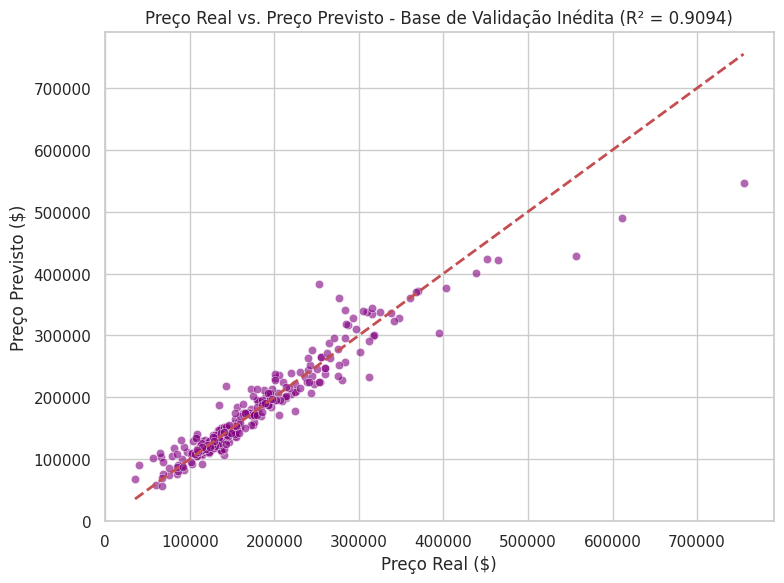

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_val, y=y_pred_val, alpha=0.6, color='purple')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)

plt.title(f'Preço Real vs. Preço Previsto - Base de Validação Inédita (R² = {r2_final:.4f})')
plt.xlabel('Preço Real ($)')
plt.ylabel('Preço Previsto ($)')
plt.tight_layout()
plt.show()

### 8) Deploy

In [34]:
joblib.dump(melhor_modelo_cat, 'modelo_imoveis_catboost.pkl')
joblib.dump(list(X.columns), 'colunas_modelo.pkl')
print("\n💾 Arquivos atualizados e salvos com sucesso!")


💾 Arquivos atualizados e salvos com sucesso!
